<div style="background:#1F3864;padding:18px 24px;border-radius:8px;margin-bottom:12px"><h2 style="color:#A8C8E8;margin:0">Digitalization, AI &amp; XAI in Healthcare</h2><h3 style="color:white;margin:4px 0">NB4 — Route 2c: Surrogate, Anchors &amp; Counterfactuals  ·  Dataset B: Heart Disease</h3><p style="color:#D0E4F4;margin:4px 0 0">Module 2 | Prof. Dr. Utku Kose | Universidad Panamericana</p></div>

## Lecture Notes

This notebook covers **rule-based and actionable** explanation methods.
Primary dataset: **Dataset B (Heart Disease)** — the richer feature set produces more
clinically informative rules and counterfactuals than Dataset A.

The final section (Section 6) runs a **cross-dataset comparison** of all four methods
side-by-side on both Dataset A and Dataset B to consolidate the course learning.

| Section | Method | Dataset | Output |
|---|---|---|---|
| 1 | Global Surrogate Tree | B | Decision protocol (ward card) |
| 2 | Anchors (high-precision rules) | B | IF-THEN guarantee |
| 3 | Counterfactuals (single) | B | "What-if" intervention |
| 4 | DiCE-style diverse CFs | B | Multiple actionable pathways |
| 5 | Clinical communication | B | Three-audience exercise |
| 6 | **Cross-dataset comparison** | **A + B** | Methods on both diseases |

### Counterfactual optimisation (Wachter et al., 2017)
$$\min_{x'} \; \text{loss}(f(x'), y') + \lambda \cdot d(x, x')$$


## Setup — Datasets A and B

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'font.size':11})
ACCENT='#E84855'; SAFE='#27AE60'; NEUTRAL='#2E75B6'

# ── Dataset A: Pima Indians Diabetes  (UCI ML Repository) ────────────────────
# Source: Smith, J.W. et al. (1988). Using the ADAP learning algorithm to
#         forecast the onset of diabetes mellitus. SCAMC Proceedings, 261-265.
#         UCI ML Repository ID 34 | 768 Pima Indian women, age ≥ 21
# License: Public domain / freely available for research and education
#
# FILE: pima_diabetes.csv  — must be in the same folder as this notebook.
# If missing, download from one of these sources:
#   • https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data
#     (no header row — rename to pima_diabetes.csv)
#   • https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
#     (diabetes.csv with header — rename to pima_diabetes.csv)

import os, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

FILE_A = 'pima_diabetes.csv'
COLS_A = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

if not os.path.exists(FILE_A):
    raise FileNotFoundError(
        f"'{FILE_A}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets"
        "/master/pima-indians-diabetes.data  (rename to pima_diabetes.csv)")

# Handles: file with header, duplicate header row, file without header
_raw = pd.read_csv(FILE_A, header=0)
_raw = _raw[_raw.iloc[:, 0].astype(str) != _raw.columns[0]]  # drop duplicate headers
if _raw.columns[0] != 'Pregnancies':
    _raw.columns = COLS_A
data_A = _raw.reset_index(drop=True)
data_A = data_A.apply(pd.to_numeric, errors='coerce').dropna()
data_A['Outcome'] = data_A['Outcome'].astype(int)

FEAT_A = [c for c in data_A.columns if c != 'Outcome']
X_A = data_A[FEAT_A]; y_A = data_A['Outcome']
Xtr_A,Xte_A,ytr_A,yte_A = train_test_split(X_A,y_A,test_size=0.2,random_state=42,stratify=y_A)
print(f'Dataset A — Pima Diabetes (UCI, original): {len(data_A)} patients | Diabetic: {y_A.mean():.1%}')
print(f'Features ({len(FEAT_A)}): {FEAT_A}')

# ── Dataset B: Cleveland Heart Disease  (UCI ML Repository) ──────────────────
# Source: Detrano, R. et al. (1989). International application of a new
#         probability algorithm for the diagnosis of coronary artery disease.
#         American Journal of Cardiology, 64(5), 304-310. UCI ML Repository ID 45
# License: Public domain / freely available for research and education
#
# FILE: cleveland_heart.csv  — must be in the same folder as this notebook.
# If missing, download from one of these sources:
#   • https://raw.githubusercontent.com/jbrownlee/Datasets/master/heart-disease.csv
#     (with header — rename to cleveland_heart.csv)
#   • https://archive.ics.uci.edu/dataset/45/heart+disease
#     (processed.cleveland.data — no header, has '?' missing values)

FILE_B = 'cleveland_heart.csv'
COLS_B = ['age','sex','cp','trestbps','chol','fbs','restecg',
          'thalach','exang','oldpeak','slope','ca','thal','target']

if not os.path.exists(FILE_B):
    raise FileNotFoundError(
        f"'{FILE_B}' not found in the current directory.\n"
        "Place the file in the same folder as this notebook.\n"
        "Download: https://raw.githubusercontent.com/jbrownlee/Datasets"
        "/master/heart-disease.csv  (rename to cleveland_heart.csv)")

data_B = pd.read_csv(FILE_B)
if 'target' not in data_B.columns:
    data_B.columns = COLS_B
data_B['target'] = data_B['target'].astype(int)

FEAT_B = [c for c in data_B.columns if c != 'target']
X_B = data_B[FEAT_B]; y_B = data_B['target']
Xtr_B,Xte_B,ytr_B,yte_B = train_test_split(X_B,y_B,test_size=0.2,random_state=42,stratify=y_B)
print(f'Dataset B — Cleveland Heart Disease (UCI, original): {len(data_B)} patients | Disease: {y_B.mean():.1%}')
print(f'Features ({len(FEAT_B)}): {FEAT_B}')

# ── Train GBM models ──────────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
Xtr_A=Xtr_A.astype(float); Xte_A=Xte_A.astype(float)
Xtr_B=Xtr_B.astype(float); Xte_B=Xte_B.astype(float)
gbm_A=GradientBoostingClassifier(n_estimators=250,max_depth=4,learning_rate=0.08,random_state=42).fit(Xtr_A,ytr_A)
gbm_B=GradientBoostingClassifier(n_estimators=250,max_depth=4,learning_rate=0.08,random_state=42).fit(Xtr_B,ytr_B)
print(f'GBM-A AUC: {roc_auc_score(yte_A,gbm_A.predict_proba(Xte_A)[:,1]):.3f}  |  GBM-B AUC: {roc_auc_score(yte_B,gbm_B.predict_proba(Xte_B)[:,1]):.3f}')

# ── High-risk patient from Dataset B ─────────────────────────────────────────
high_B_idx=Xte_B[yte_B==1].index[0]
high_B_pos=Xte_B.index.get_loc(high_B_idx)
patient_B=Xte_B.iloc[high_B_pos].copy()
pred_B=gbm_B.predict_proba(patient_B.values.reshape(1,-1))[0,1]
print(f'Explaining patient — heart disease risk: {pred_B:.1%}')
print(f'GBM-A AUC: {roc_auc_score(yte_A,gbm_A.predict_proba(Xte_A)[:,1]):.3f}  |  GBM-B AUC: {roc_auc_score(yte_B,gbm_B.predict_proba(Xte_B)[:,1]):.3f}')

# ── High-risk patient from Dataset B ────────────────────────────────────────
high_B_idx=Xte_B[yte_B==1].index[0]
high_B_pos=Xte_B.index.get_loc(high_B_idx)
patient_B=Xte_B.iloc[high_B_pos].copy()
pred_B=gbm_B.predict_proba(patient_B.values.reshape(1,-1))[0,1]
print(f'Explaining patient — heart disease risk: {pred_B:.1%}')

Dataset A — Pima Diabetes (UCI, original): 768 patients | Diabetic: 34.9%
Features (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Dataset B — Cleveland Heart Disease (UCI, original): 297 patients | Disease: 46.1%
Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
GBM-A AUC: 0.814  |  GBM-B AUC: 0.887
Explaining patient — heart disease risk: 99.2%
GBM-A AUC: 0.814  |  GBM-B AUC: 0.887
Explaining patient — heart disease risk: 99.2%


---
## Section 1 — Global Surrogate Decision Tree
🗂 **Dataset B: Heart Disease**

Train a decision tree to **mimic the GBM's predictions** (not the true labels).

**Fidelity** = how often surrogate agrees with black-box:
$$\text{Fidelity} = \frac{1}{n}|\{i : g(x_i) = f(x_i)\}|$$

> **Clinical use:** The surrogate tree at depth 4 becomes the hospital's AI audit protocol —
> a flowchart clinicians can follow manually to validate or challenge the model's output.


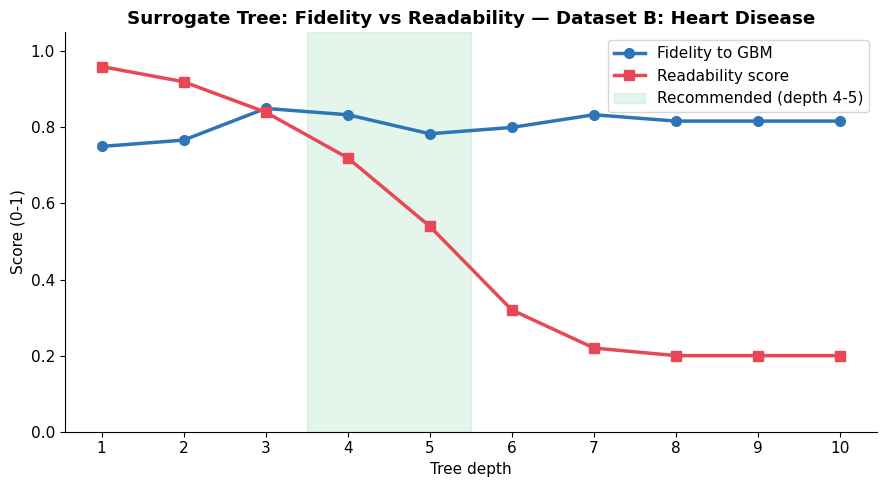

In [4]:
gbm_B_preds_tr = gbm_B.predict(Xtr_B)
gbm_B_preds_te = gbm_B.predict(Xte_B)

depths = range(1, 11)
fids_B, reads_B = [], []
for d in depths:
    s = DecisionTreeClassifier(max_depth=d, random_state=42).fit(Xtr_B, gbm_B_preds_tr)
    fids_B.append((s.predict(Xte_B) == gbm_B_preds_te).mean())
    reads_B.append(max(0, 1 - s.get_n_leaves() / 50))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(depths), fids_B,  'o-', color=NEUTRAL, lw=2.5, ms=7, label='Fidelity to GBM')
ax.plot(list(depths), reads_B, 's-', color=ACCENT,  lw=2.5, ms=7, label='Readability score')
ax.axvspan(3.5, 5.5, alpha=0.12, color=SAFE, label='Recommended (depth 4-5)')
ax.set_xlabel('Tree depth'); ax.set_ylabel('Score (0-1)')
ax.set_title('Surrogate Tree: Fidelity vs Readability — Dataset B: Heart Disease',
             fontweight='bold')
ax.set_xticks(list(depths)); ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

Surrogate fidelity (Dataset B): 83.3%


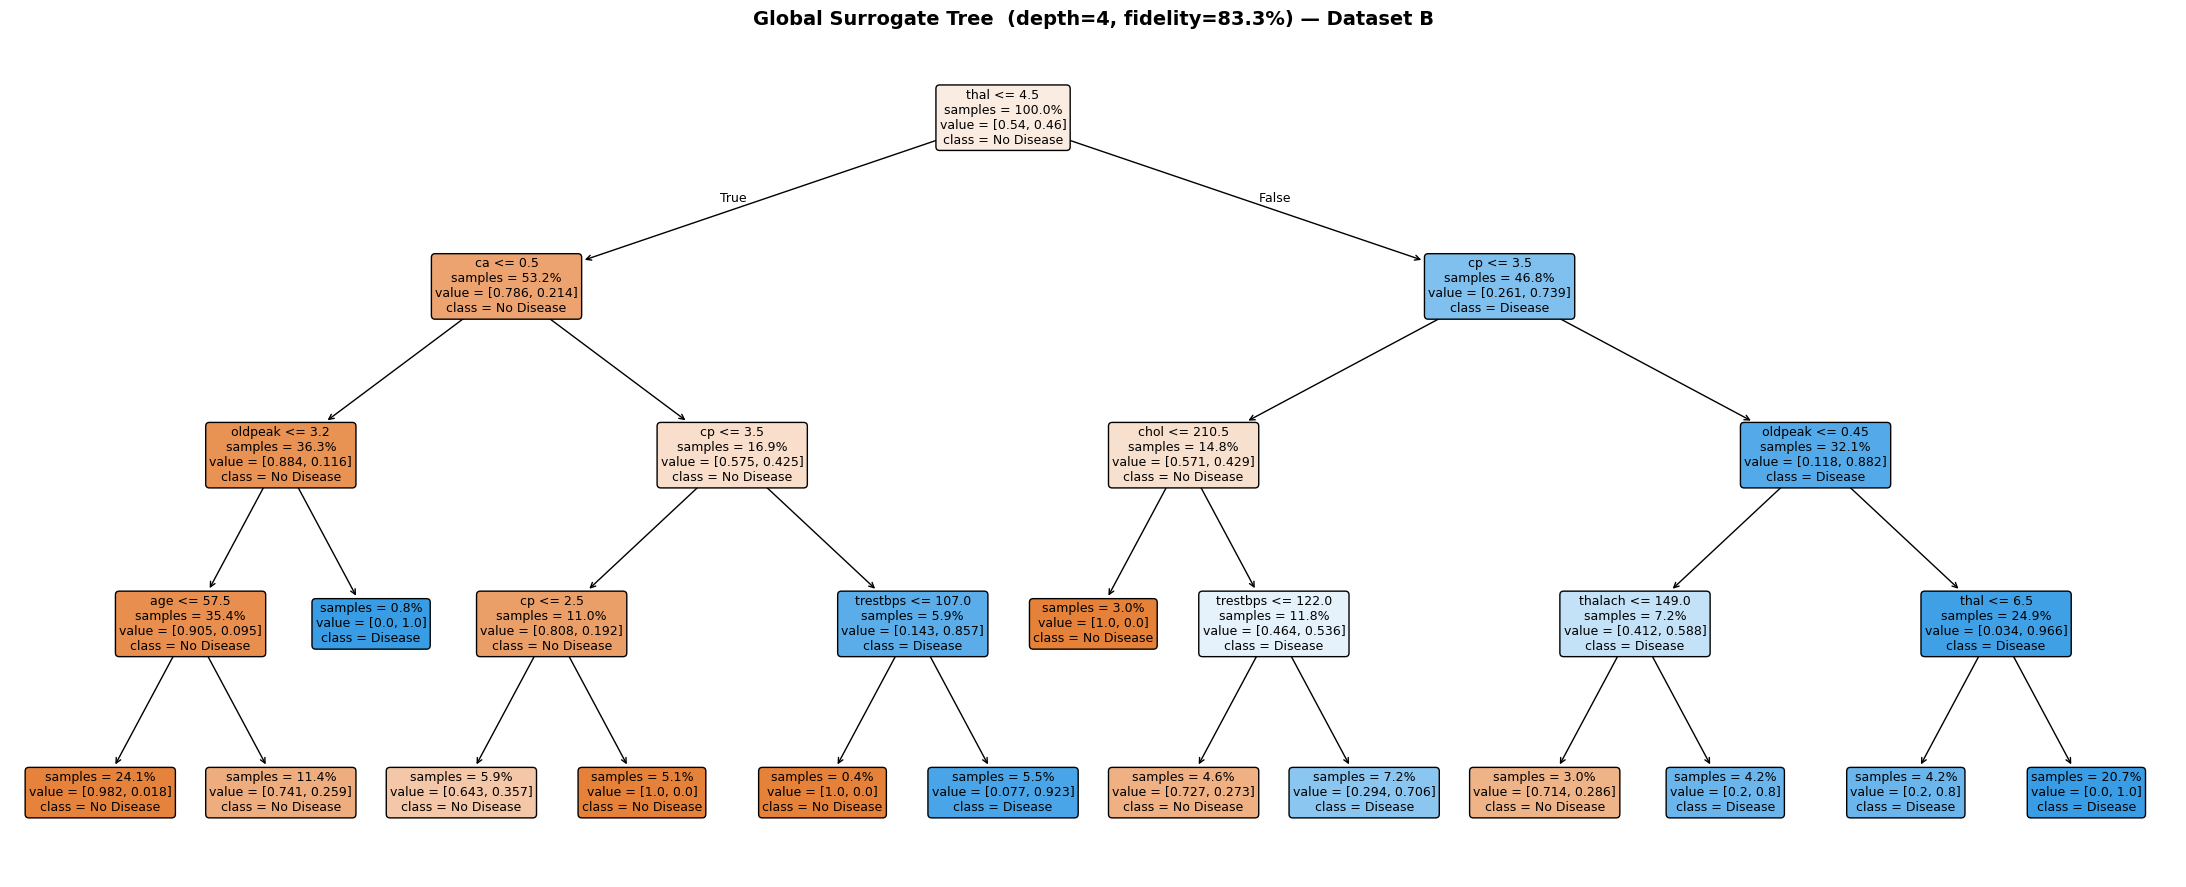

Clinical protocol (depth ≤ 3):
|--- thal <= 4.50
|   |--- ca <= 0.50
|   |   |--- oldpeak <= 3.20
|   |   |   |--- age <= 57.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  57.50
|   |   |   |   |--- class: 0
|   |   |--- oldpeak >  3.20
|   |   |   |--- class: 1
|   |--- ca >  0.50
|   |   |--- cp <= 3.50
|   |   |   |--- cp <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- cp >  2.50
|   |   |   |   |--- class: 0
|   |   |--- cp >  3.50
|   |   |   |--- trestbps <= 107.00
|   |   |   |   |--- class: 0
|   |   |   |--- trestbps >  107.00
|   |   |   |   |--- class: 1
|--- thal >  4.50
|   |--- cp <= 3.50
|   |   |--- chol <= 210.50
|   |   |   |--- class: 0
|   |   |--- chol >  210.50
|   |   |   |--- trestbps <= 122.00
|   |   |   |   |--- class: 0
|   |   |   |--- trestbps >  122.00
|   |   |   |   |--- class: 1
|   |--- cp >  3.50
|   |   |--- oldpeak <= 0.45
|   |   |   |--- thalach <= 149.00
|   |   |   |   |--- class: 0
|   |   |   |--- thalach >  149.00
|   |   | 

In [5]:
surrogate_B = DecisionTreeClassifier(max_depth=4, random_state=42)
surrogate_B.fit(Xtr_B, gbm_B_preds_tr)
fidelity_B = (surrogate_B.predict(Xte_B) == gbm_B_preds_te).mean()
print(f'Surrogate fidelity (Dataset B): {fidelity_B:.1%}')

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(surrogate_B, feature_names=FEAT_B,
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, ax=ax, fontsize=9,
          impurity=False, proportion=True)
ax.set_title(f'Global Surrogate Tree  (depth=4, fidelity={fidelity_B:.1%}) — Dataset B',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Clinical protocol (depth ≤ 3):')
print('='*60)
print(export_text(surrogate_B, feature_names=FEAT_B, max_depth=3))

---
## Section 2 — Anchors (High-Precision IF-THEN Rules)
🗂 **Dataset B: Heart Disease**

An Anchor rule guarantees the prediction with precision ≥ threshold,
**regardless of all other feature values**:
$$P(f(z) = f(x) \mid z \text{ satisfies Anchor}) \geq 1 - \varepsilon$$

> *"IF thal = 3 AND ca ≥ 1 AND exang = 1, THEN the model always predicts heart disease (precision ≥ 87%), regardless of age, cholesterol, or any other feature."*

This is stronger than a LIME weight — it is a **guarantee with a stated confidence**.


In [7]:
def find_anchor(model, patient, feature_names, X_test,
                precision_threshold=0.85, max_feats=5):
    target = model.predict(patient.values.reshape(1,-1))[0]
    conds  = {}
    remaining = list(range(len(feature_names)))
    best_prec = 0
    while remaining and len(conds) < max_feats:
        best_feat = best_dir = None
        for fi in remaining:
            fv = patient.iloc[fi]
            for direction in ['>', '<=']:
                test = {**conds, fi: (direction, fv)}
                valid = np.ones(len(X_test), dtype=bool)
                for k, (d, v) in test.items():
                    if d == '>': valid &= (X_test.iloc[:, k] > v)
                    else:        valid &= (X_test.iloc[:, k] <= v)
                if valid.sum() < 5: continue
                prec = (model.predict(X_test[valid]) == target).mean()
                if prec > best_prec:
                    best_prec = prec; best_feat = fi; best_dir = direction
        if best_feat is None: break
        conds[best_feat] = (best_dir, patient.iloc[best_feat])
        if best_prec >= precision_threshold: break
        remaining.remove(best_feat)
    return conds, best_prec

anchor_B, prec_B = find_anchor(gbm_B, patient_B, FEAT_B, Xte_B)
label_B = 'Heart Disease' if gbm_B.predict(patient_B.values.reshape(1,-1))[0] else 'No Disease'

print(f'ANCHOR EXPLANATION — Dataset B (precision: {prec_B:.1%})')
print(f'Prediction: {label_B}'); print('-'*55)
print('IF ALL of the following conditions hold:')
for fi, (direction, value) in anchor_B.items():
    sym = '>' if direction == '>' else '≤'
    print(f'  {FEAT_B[fi]:15s} {sym} {value:.1f}')
print(f'THEN: {label_B}  (precision ≥ {prec_B:.1%})')
print('(holds regardless of all other feature values)')

# Show how many test patients satisfy this anchor
valid_anchor = np.ones(len(Xte_B), dtype=bool)
for fi, (d, v) in anchor_B.items():
    if d == '>': valid_anchor &= (Xte_B.iloc[:, fi] > v)
    else:        valid_anchor &= (Xte_B.iloc[:, fi] <= v)
print(f'\n{valid_anchor.sum()} test patients satisfy this anchor ({valid_anchor.mean():.1%})')

ANCHOR EXPLANATION — Dataset B (precision: 86.7%)
Prediction: Heart Disease
-------------------------------------------------------
IF ALL of the following conditions hold:
  exang           > 0.0
THEN: Heart Disease  (precision ≥ 86.7%)
(holds regardless of all other feature values)

15 test patients satisfy this anchor (25.0%)


---
## Section 3 — Counterfactual Explanations
🗂 **Dataset B: Heart Disease**

*What is the smallest clinically feasible change to reduce this patient's predicted risk?*

Only **actionable** features are targeted (not sex, ca — the latter is from angiography).


Original heart disease risk: 99.2%
 Feature  Original  Counterfactual  New risk %  Risk reduction pp
trestbps     132.0           103.4        17.6               81.7
    chol     224.0            89.6        81.7               17.5
 oldpeak       3.2             1.3        89.0               10.3
     age      58.0            61.8        90.5                8.8
 thalach     173.0           177.4        97.2                2.0
   slope       1.0             1.0        99.2                0.0


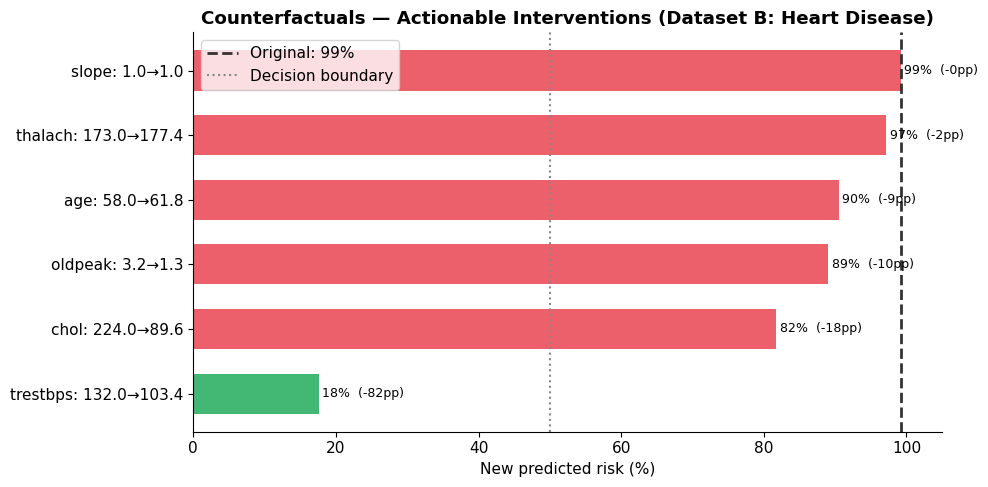

In [8]:
# Actionable features: things that can be modified through treatment/lifestyle
ACTIONABLE_B = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']
# Non-actionable: sex, cp (symptom), fbs (controlled), ca (angiographic finding), thal (structural)

def single_cf(model, patient, features, actionable, n_steps=120):
    orig_prob = model.predict_proba(patient.values.reshape(1,-1))[0,1]
    rows = []
    for feat in actionable:
        fi = features.index(feat)
        orig = patient.iloc[fi]
        best_prob, best_val = orig_prob, orig
        for delta in np.linspace(-0.60, 0.60, n_steps):
            cand = patient.copy(); cand.iloc[fi] = orig * (1 + delta)
            p = model.predict_proba(cand.values.reshape(1,-1))[0,1]
            if p < best_prob: best_prob, best_val = p, cand.iloc[fi]
        rows.append({'Feature': feat, 'Original': round(orig, 1),
                     'Counterfactual': round(best_val, 1),
                     'New risk %': round(best_prob*100, 1),
                     'Risk reduction pp': round((orig_prob-best_prob)*100, 1)})
    return pd.DataFrame(rows), orig_prob

cf_df_B, orig_risk_B = single_cf(gbm_B, patient_B, FEAT_B, ACTIONABLE_B)
print(f'Original heart disease risk: {orig_risk_B:.1%}')
print(cf_df_B.sort_values('Risk reduction pp', ascending=False).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
cf_s = cf_df_B.sort_values('New risk %')
colors = [SAFE if r<50 else NEUTRAL if r<70 else ACCENT for r in cf_s['New risk %']]
bars = ax.barh(
    [f"{r['Feature']}: {r['Original']}→{r['Counterfactual']}" for _,r in cf_s.iterrows()],
    cf_s['New risk %'], color=colors, alpha=0.87, height=0.62)
ax.axvline(orig_risk_B*100, color='#333', lw=2, ls='--',
           label=f'Original: {orig_risk_B:.0%}')
ax.axvline(50, color='#888', lw=1.5, ls=':', label='Decision boundary')
ax.set_xlabel('New predicted risk (%)')
ax.set_title('Counterfactuals — Actionable Interventions (Dataset B: Heart Disease)',
             fontweight='bold')
ax.legend(); ax.set_xlim(0, 105)
for bar, (_, row) in zip(bars, cf_s.iterrows()):
    ax.text(row['New risk %']+0.5, bar.get_y()+bar.get_height()/2,
            f"{row['New risk %']:.0f}%  (-{row['Risk reduction pp']:.0f}pp)",
            va='center', fontsize=9)
plt.tight_layout(); plt.show()

---
## Section 4 — DiCE-style Diverse Counterfactuals
🗂 **Dataset B: Heart Disease**

DiCE generates **multiple diverse** counterfactuals so patients have a choice of pathways.

> **Clinical value:** One patient can target blood pressure reduction through medication;
> another prefers cardiac rehabilitation to improve max heart rate (thalach);
> a third reduces ST depression (oldpeak) through lifestyle change. Diverse CFs
> support genuine **shared decision-making**.


In [9]:
def diverse_cfs(model, patient, features, actionable,
                n_cf=4, n_iter=250, lam=0.3):
    fi_map = {f: i for i, f in enumerate(features)}
    ai     = [fi_map[f] for f in actionable]
    target = 1 - model.predict(patient.values.reshape(1,-1))[0]
    cfs    = []; np.random.seed(42)
    for _ in range(n_cf):
        cf = patient.copy()
        for fi in ai: cf.iloc[fi] *= np.random.uniform(0.6, 1.4)
        best = cf.copy(); best_loss = float('inf')
        for step in range(n_iter):
            trial = best.copy()
            fi_r  = np.random.choice(ai)
            trial.iloc[fi_r] += np.random.uniform(-0.15,0.15)*abs(best.iloc[fi_r])+0.5
            p = model.predict_proba(trial.values.reshape(1,-1))[0, target]
            dist = np.mean([(trial.iloc[fi]-patient.iloc[fi])**2 /
                            (patient.iloc[fi]**2+1e-6) for fi in ai])
            div = -lam*sum(
                np.mean([(trial.iloc[fi]-c.iloc[fi])**2 for fi in ai])
                for c in cfs)
            loss = (1-p)**2 + 0.2*dist + div
            if loss < best_loss: best_loss, best = loss, trial.copy()
        if model.predict(best.values.reshape(1,-1))[0] == target:
            cfs.append(best)
    return cfs

cfs_B = diverse_cfs(gbm_B, patient_B, FEAT_B, ACTIONABLE_B, n_cf=4)
print(f'Generated {len(cfs_B)} diverse counterfactuals | Original risk: {pred_B:.1%}')
for i, cf in enumerate(cfs_B):
    cr = gbm_B.predict_proba(cf.values.reshape(1,-1))[0,1]
    changes = [(f, patient_B[f], cf[f]) for f in ACTIONABLE_B
               if abs(cf[f]-patient_B[f])/(abs(patient_B[f])+1e-6) > 0.04]
    print(f'  CF #{i+1}: new risk={cr:.0%}  |',
          ' | '.join(f'{f}: {o:.1f}→{c:.1f}' for f,o,c in changes[:3]))

Generated 2 diverse counterfactuals | Original risk: 99.2%
  CF #1: new risk=14%  | age: 58.0→53.2 | trestbps: 132.0→147.0 | chol: 224.0→258.2
  CF #2: new risk=13%  | age: 58.0→11.3 | trestbps: 132.0→27.3 | chol: 224.0→803.5


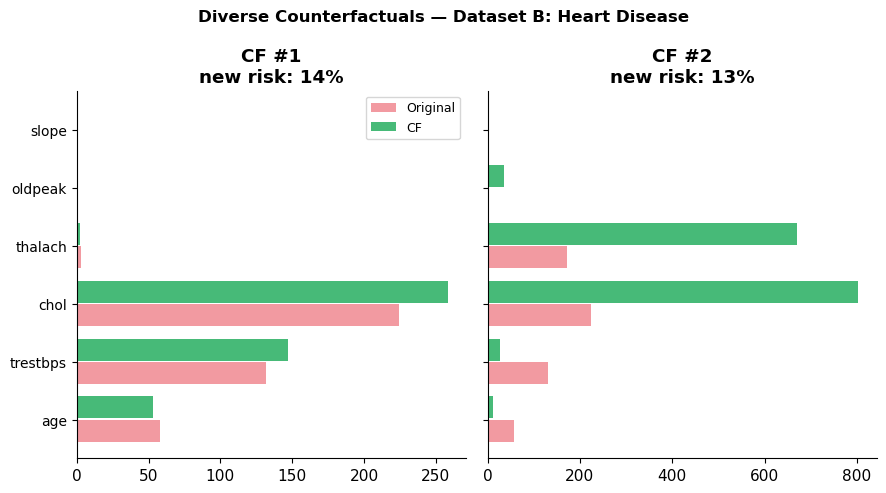

In [10]:
# Visualise diverse CFs
if len(cfs_B) >= 2:
    fig, axes = plt.subplots(1, min(len(cfs_B),4), figsize=(4.5*min(len(cfs_B),4), 5), sharey=True)
    if len(cfs_B)==1: axes=[axes]
    for cf_num, (cf, ax) in enumerate(zip(cfs_B, axes)):
        cr = gbm_B.predict_proba(cf.values.reshape(1,-1))[0,1]
        changes = {f:(patient_B[f],cf[f]) for f in ACTIONABLE_B
                   if abs(cf[f]-patient_B[f])/(abs(patient_B[f])+1e-6)>0.04}
        if not changes: changes = {ACTIONABLE_B[0]: (patient_B[ACTIONABLE_B[0]],
                                                      cfs_B[cf_num][ACTIONABLE_B[0]])}
        feats_cf=list(changes.keys())
        orig_v=[changes[f][0] for f in feats_cf]
        cf_v  =[changes[f][1] for f in feats_cf]
        y_pos=range(len(feats_cf))
        ax.barh([y+0.0  for y in y_pos],orig_v,0.38,color=ACCENT,alpha=0.55,label='Original')
        ax.barh([y+0.40 for y in y_pos],cf_v,  0.38,color=SAFE,  alpha=0.85,label='CF')
        ax.set_yticks([y+0.19 for y in y_pos]); ax.set_yticklabels(feats_cf,fontsize=10)
        ax.set_title(f'CF #{cf_num+1}\nnew risk: {cr:.0%}',fontweight='bold')
        if cf_num==0: ax.legend(fontsize=9)
    plt.suptitle('Diverse Counterfactuals — Dataset B: Heart Disease',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Fewer than 2 counterfactuals found — try increasing n_iter.')

---
## Section 5 — Clinical Communication: Three-Audience Exercise
🗂 **Dataset B: Heart Disease**

The same prediction translated into three different explanation formats
for three different clinical audiences.


In [12]:
import shap
exp_B2 = shap.TreeExplainer(gbm_B)
sv_B2  = exp_B2.shap_values(Xte_B)
bv_B2  = float(np.array(exp_B2.expected_value).flat[0])
sv_p   = sv_B2[high_B_pos]
best_cf_row = cf_df_B.sort_values('Risk reduction pp', ascending=False).iloc[0]

print('='*65)
print('AUDIENCE 1 — PATIENT (Counterfactual, plain language)')
print('='*65)
print(f'Your heart disease risk is currently {pred_B:.0%}.')
print(f'If your {best_cf_row["Feature"]} could change from')
print(f'{best_cf_row["Original"]} to {best_cf_row["Counterfactual"]},')
print(f'your estimated risk would drop to {best_cf_row["New risk %"]:.0f}%.')
print(f'That is a reduction of {best_cf_row["Risk reduction pp"]:.0f} percentage points.')
print()
print('='*65)
print('AUDIENCE 2 — CARDIOLOGIST (SHAP waterfall, top drivers)')
print('='*65)
print(f'Baseline population risk: {bv_B2:.0%}')
top3=sorted(zip(FEAT_B,sv_p),key=lambda x:-abs(x[1]))[:3]
for feat,sv in top3:
    d='increases' if sv>0 else 'decreases'
    print(f'  {feat}: SHAP={sv:+.3f} ({d} risk from baseline)')
print()
print('='*65)
print('AUDIENCE 3 — HOSPITAL AUDITOR (Surrogate protocol)')
print('='*65)
print(f'Surrogate fidelity: {fidelity_B:.1%}')
sur3=DecisionTreeClassifier(max_depth=3,random_state=42)
sur3.fit(Xtr_B,gbm_B.predict(Xtr_B))
print(export_text(sur3,feature_names=FEAT_B,max_depth=2)[:700])

AUDIENCE 1 — PATIENT (Counterfactual, plain language)
Your heart disease risk is currently 99%.
If your trestbps could change from
132.0 to 103.4,
your estimated risk would drop to 18%.
That is a reduction of 82 percentage points.

AUDIENCE 2 — CARDIOLOGIST (SHAP waterfall, top drivers)
Baseline population risk: -49%
  oldpeak: SHAP=+3.620 (increases risk from baseline)
  ca: SHAP=+2.584 (increases risk from baseline)
  cp: SHAP=-2.151 (decreases risk from baseline)

AUDIENCE 3 — HOSPITAL AUDITOR (Surrogate protocol)
Surrogate fidelity: 83.3%
|--- thal <= 4.50
|   |--- ca <= 0.50
|   |   |--- oldpeak <= 3.20
|   |   |   |--- class: 0
|   |   |--- oldpeak >  3.20
|   |   |   |--- class: 1
|   |--- ca >  0.50
|   |   |--- cp <= 3.50
|   |   |   |--- class: 0
|   |   |--- cp >  3.50
|   |   |   |--- class: 1
|--- thal >  4.50
|   |--- cp <= 3.50
|   |   |--- chol <= 210.50
|   |   |   |--- class: 0
|   |   |--- chol >  210.50
|   |   |   |--- class: 1
|   |--- cp >  3.50
|   |   |--- oldp

---
## Section 6 — Cross-Dataset Comparison: A (Diabetes) vs B (Heart Disease)
🗂 **Both Datasets**

This capstone exercise applies all four methods to **both datasets** side-by-side,
asking: do the same XAI techniques reveal similar or different clinical stories
when the disease and feature set change?


In [13]:
# ── Surrogate fidelity comparison ────────────────────────────────────────
sur_A = DecisionTreeClassifier(max_depth=4,random_state=42)
sur_A.fit(Xtr_A, gbm_A.predict(Xtr_A))
fid_A = (sur_A.predict(Xte_A)==gbm_A.predict(Xte_A)).mean()
print(f'Surrogate fidelity  — Dataset A (Diabetes):     {fid_A:.1%}')
print(f'Surrogate fidelity  — Dataset B (Heart Disease): {fidelity_B:.1%}')

# ── Anchor on Dataset A ──────────────────────────────────────────────────
high_A_idx=Xte_A[yte_A==1].index[0]
patient_A=Xte_A.iloc[Xte_A.index.get_loc(high_A_idx)].copy()
anchor_A,prec_A=find_anchor(gbm_A,patient_A,FEAT_A,Xte_A)
print(f'\nAnchor precision — Dataset A (Diabetes):     {prec_A:.1%}')
print(f'Anchor precision — Dataset B (Heart Disease): {prec_B:.1%}')
print('\nDataset A anchor conditions:')
for fi,(d,v) in anchor_A.items():
    print(f'  {FEAT_A[fi]:28s} {d} {v:.1f}')
print('\nDataset B anchor conditions:')
for fi,(d,v) in anchor_B.items():
    print(f'  {FEAT_B[fi]:15s} {d} {v:.1f}')

Surrogate fidelity  — Dataset A (Diabetes):     86.4%
Surrogate fidelity  — Dataset B (Heart Disease): 83.3%

Anchor precision — Dataset A (Diabetes):     100.0%
Anchor precision — Dataset B (Heart Disease): 86.7%

Dataset A anchor conditions:
  Pregnancies                  > 7.0
  Glucose                      > 114.0
  SkinThickness                <= 0.0

Dataset B anchor conditions:
  exang           > 0.0


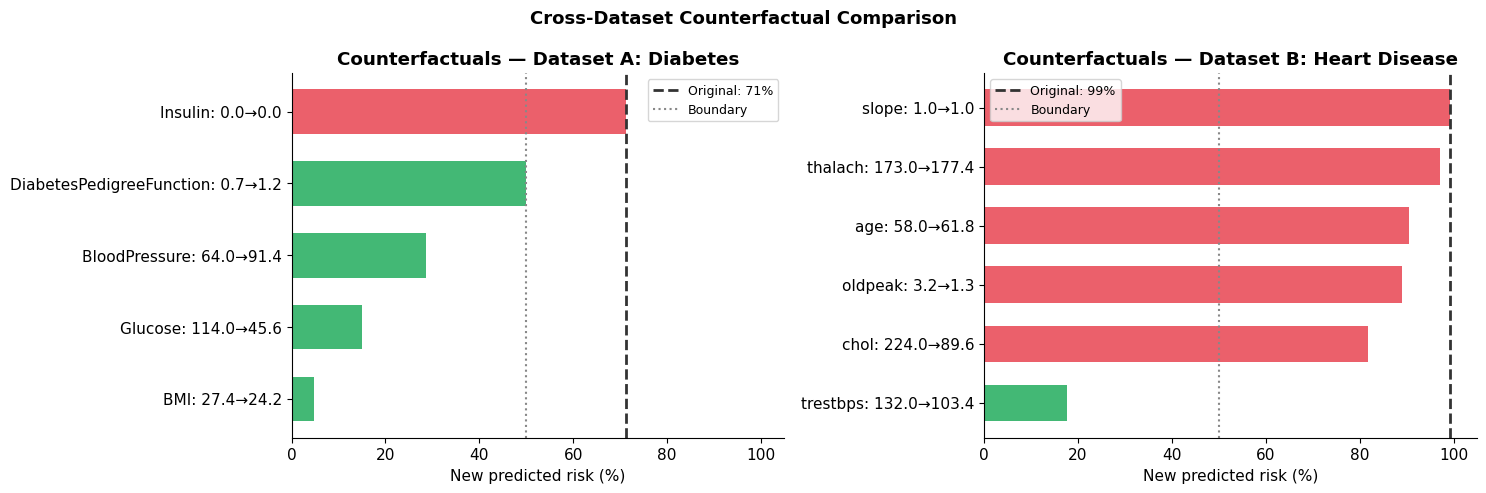


Cross-dataset reflection questions:
1. Are the actionable features different between the two diseases?
2. Which disease allows a larger risk reduction through a single feature change?
3. Are the counterfactual suggestions clinically plausible in both cases?


In [15]:
# ── Counterfactual comparison ─────────────────────────────────────────────
ACTIONABLE_A=['Glucose','BMI','Insulin','BloodPressure','DiabetesPedigreeFunction']
cf_df_A,orig_A=single_cf(gbm_A,patient_A,FEAT_A,ACTIONABLE_A)
pred_A=gbm_A.predict_proba(patient_A.values.reshape(1,-1))[0,1]

fig,axes=plt.subplots(1,2,figsize=(15,5))

for ax,cf_df,orig_risk,title in [
    (axes[0],cf_df_A,orig_A,'Dataset A: Diabetes'),
    (axes[1],cf_df_B,orig_risk_B,'Dataset B: Heart Disease')]:
    cf_s=cf_df.sort_values('New risk %')
    colors=[SAFE if r<50 else NEUTRAL if r<70 else ACCENT for r in cf_s['New risk %']]
    ax.barh(
        [f"{r['Feature']}: {r['Original']}→{r['Counterfactual']}" for _,r in cf_s.iterrows()],
        cf_s['New risk %'],color=colors,alpha=0.87,height=0.62)
    ax.axvline(orig_risk*100,color='#333',lw=2,ls='--',label=f'Original: {orig_risk:.0%}')
    ax.axvline(50,color='#888',lw=1.5,ls=':',label='Boundary')
    ax.set_xlabel('New predicted risk (%)'); ax.set_title(f'Counterfactuals — {title}',fontweight='bold')
    ax.legend(fontsize=9); ax.set_xlim(0,105)

plt.suptitle('Cross-Dataset Counterfactual Comparison',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

print('\nCross-dataset reflection questions:')
print('1. Are the actionable features different between the two diseases?')
print('2. Which disease allows a larger risk reduction through a single feature change?')
print('3. Are the counterfactual suggestions clinically plausible in both cases?')

In [16]:
# ── Final summary table ───────────────────────────────────────────────────
import shap
exp_A2=shap.TreeExplainer(gbm_A)
sv_A2=exp_A2.shap_values(Xte_A)
top_A=pd.Series(np.abs(sv_A2).mean(axis=0),index=FEAT_A).sort_values(ascending=False).index[:3].tolist()
top_B=pd.Series(np.abs(sv_B2).mean(axis=0) if 'sv_B2' in dir() else
       np.abs(exp_B2.shap_values(Xte_B)).mean(axis=0),
       index=FEAT_B).sort_values(ascending=False).index[:3].tolist()

print('='*65)
print('COURSE SUMMARY — XAI Methods Across Two Clinical Datasets')
print('='*65)
print(f'{"Method":<28} {"Dataset A (Diabetes)":<22} {"Dataset B (Heart Dis.)"}')
print('-'*65)
print(f'{"Top-3 SHAP features":<28} {str(top_A):<22} {str(top_B)}')
print(f'{"Surrogate fidelity":<28} {fid_A:.1%}                {fidelity_B:.1%}')
print(f'{"Anchor precision":<28} {prec_A:.1%}                {prec_B:.1%}')
best_A=cf_df_A.sort_values('Risk reduction pp',ascending=False).iloc[0]
best_B=cf_df_B.sort_values('Risk reduction pp',ascending=False).iloc[0]
print(f'{"Best CF feature":<28} {best_A["Feature"]:<22} {best_B["Feature"]}')
print(f'{"Max CF risk reduction":<28} {best_A["Risk reduction pp"]:.0f}pp                {best_B["Risk reduction pp"]:.0f}pp')

COURSE SUMMARY — XAI Methods Across Two Clinical Datasets
Method                       Dataset A (Diabetes)   Dataset B (Heart Dis.)
-----------------------------------------------------------------
Top-3 SHAP features          ['Glucose', 'BMI', 'Age'] ['cp', 'ca', 'thal']
Surrogate fidelity           86.4%                83.3%
Anchor precision             100.0%                86.7%
Best CF feature              BMI                    trestbps
Max CF risk reduction        67pp                82pp


---
## Summary: Rule-Based Methods Across Two Datasets

| Method | Dataset A Insight | Dataset B Insight |
|---|---|---|
| Surrogate Tree | Glucose + BMI threshold protocol | thal + ca + thalach protocol |
| Anchors | High-Glucose + high-BMI guarantee | High-thal + high-ca guarantee |
| Counterfactuals | Reduce Glucose/BMI for biggest gain | Increase thalach / reduce oldpeak |
| DiCE | Multiple diet/exercise pathways | Cardiac rehab / BP medication / both |

### Final Discussion Questions
1. The surrogate tree achieves higher fidelity on Dataset A than B. Why might this be? (Hint: consider feature types.)
2. For heart disease, counterfactuals target thalach (max heart rate). Is "increase max heart rate" a safe clinical recommendation to give to a patient?
3. Dataset B has angiographic features (ca, thal) that are revealed by invasive procedures. Should counterfactuals include these as "actionable"? What are the implications?

> **Next → NB5:** Visual/Saliency methods on **Dataset C (Chest X-ray patches)** — Grad-CAM, saliency maps, occlusion sensitivity, and TCAV applied to medical images.
